1.	Using USGS Earthquake Catalog (ComCat), retrieve information about the 1999 Mw7.7 Chi-Chi, Taiwan Earthquake. Plot a map with the event epicenter and focal mechanism (beachball) using pyGMT. Include an inset map to locate Taiwan within Asia and information about Earth's relief. Additionally, plot the locations of Taiwan's strong ground motion stations (nga_west2_stations_taiwan.csv), and use different fill colors to represent the VS30 values at the stations. Remember to include a legend to explain the color codes.

In [1]:
import pygmt
import pandas as pd
import numpy as np

According to the information found in ComCat https://earthquake.usgs.gov/earthquakes/eventpage/usp0009eq0/technical we have the event location at 23.772°N  120.982°E. The main map will be set to center around Taiwan (M121) to have a traditional rectangle map, and annotations at every 1°, ticks every 0.5°.

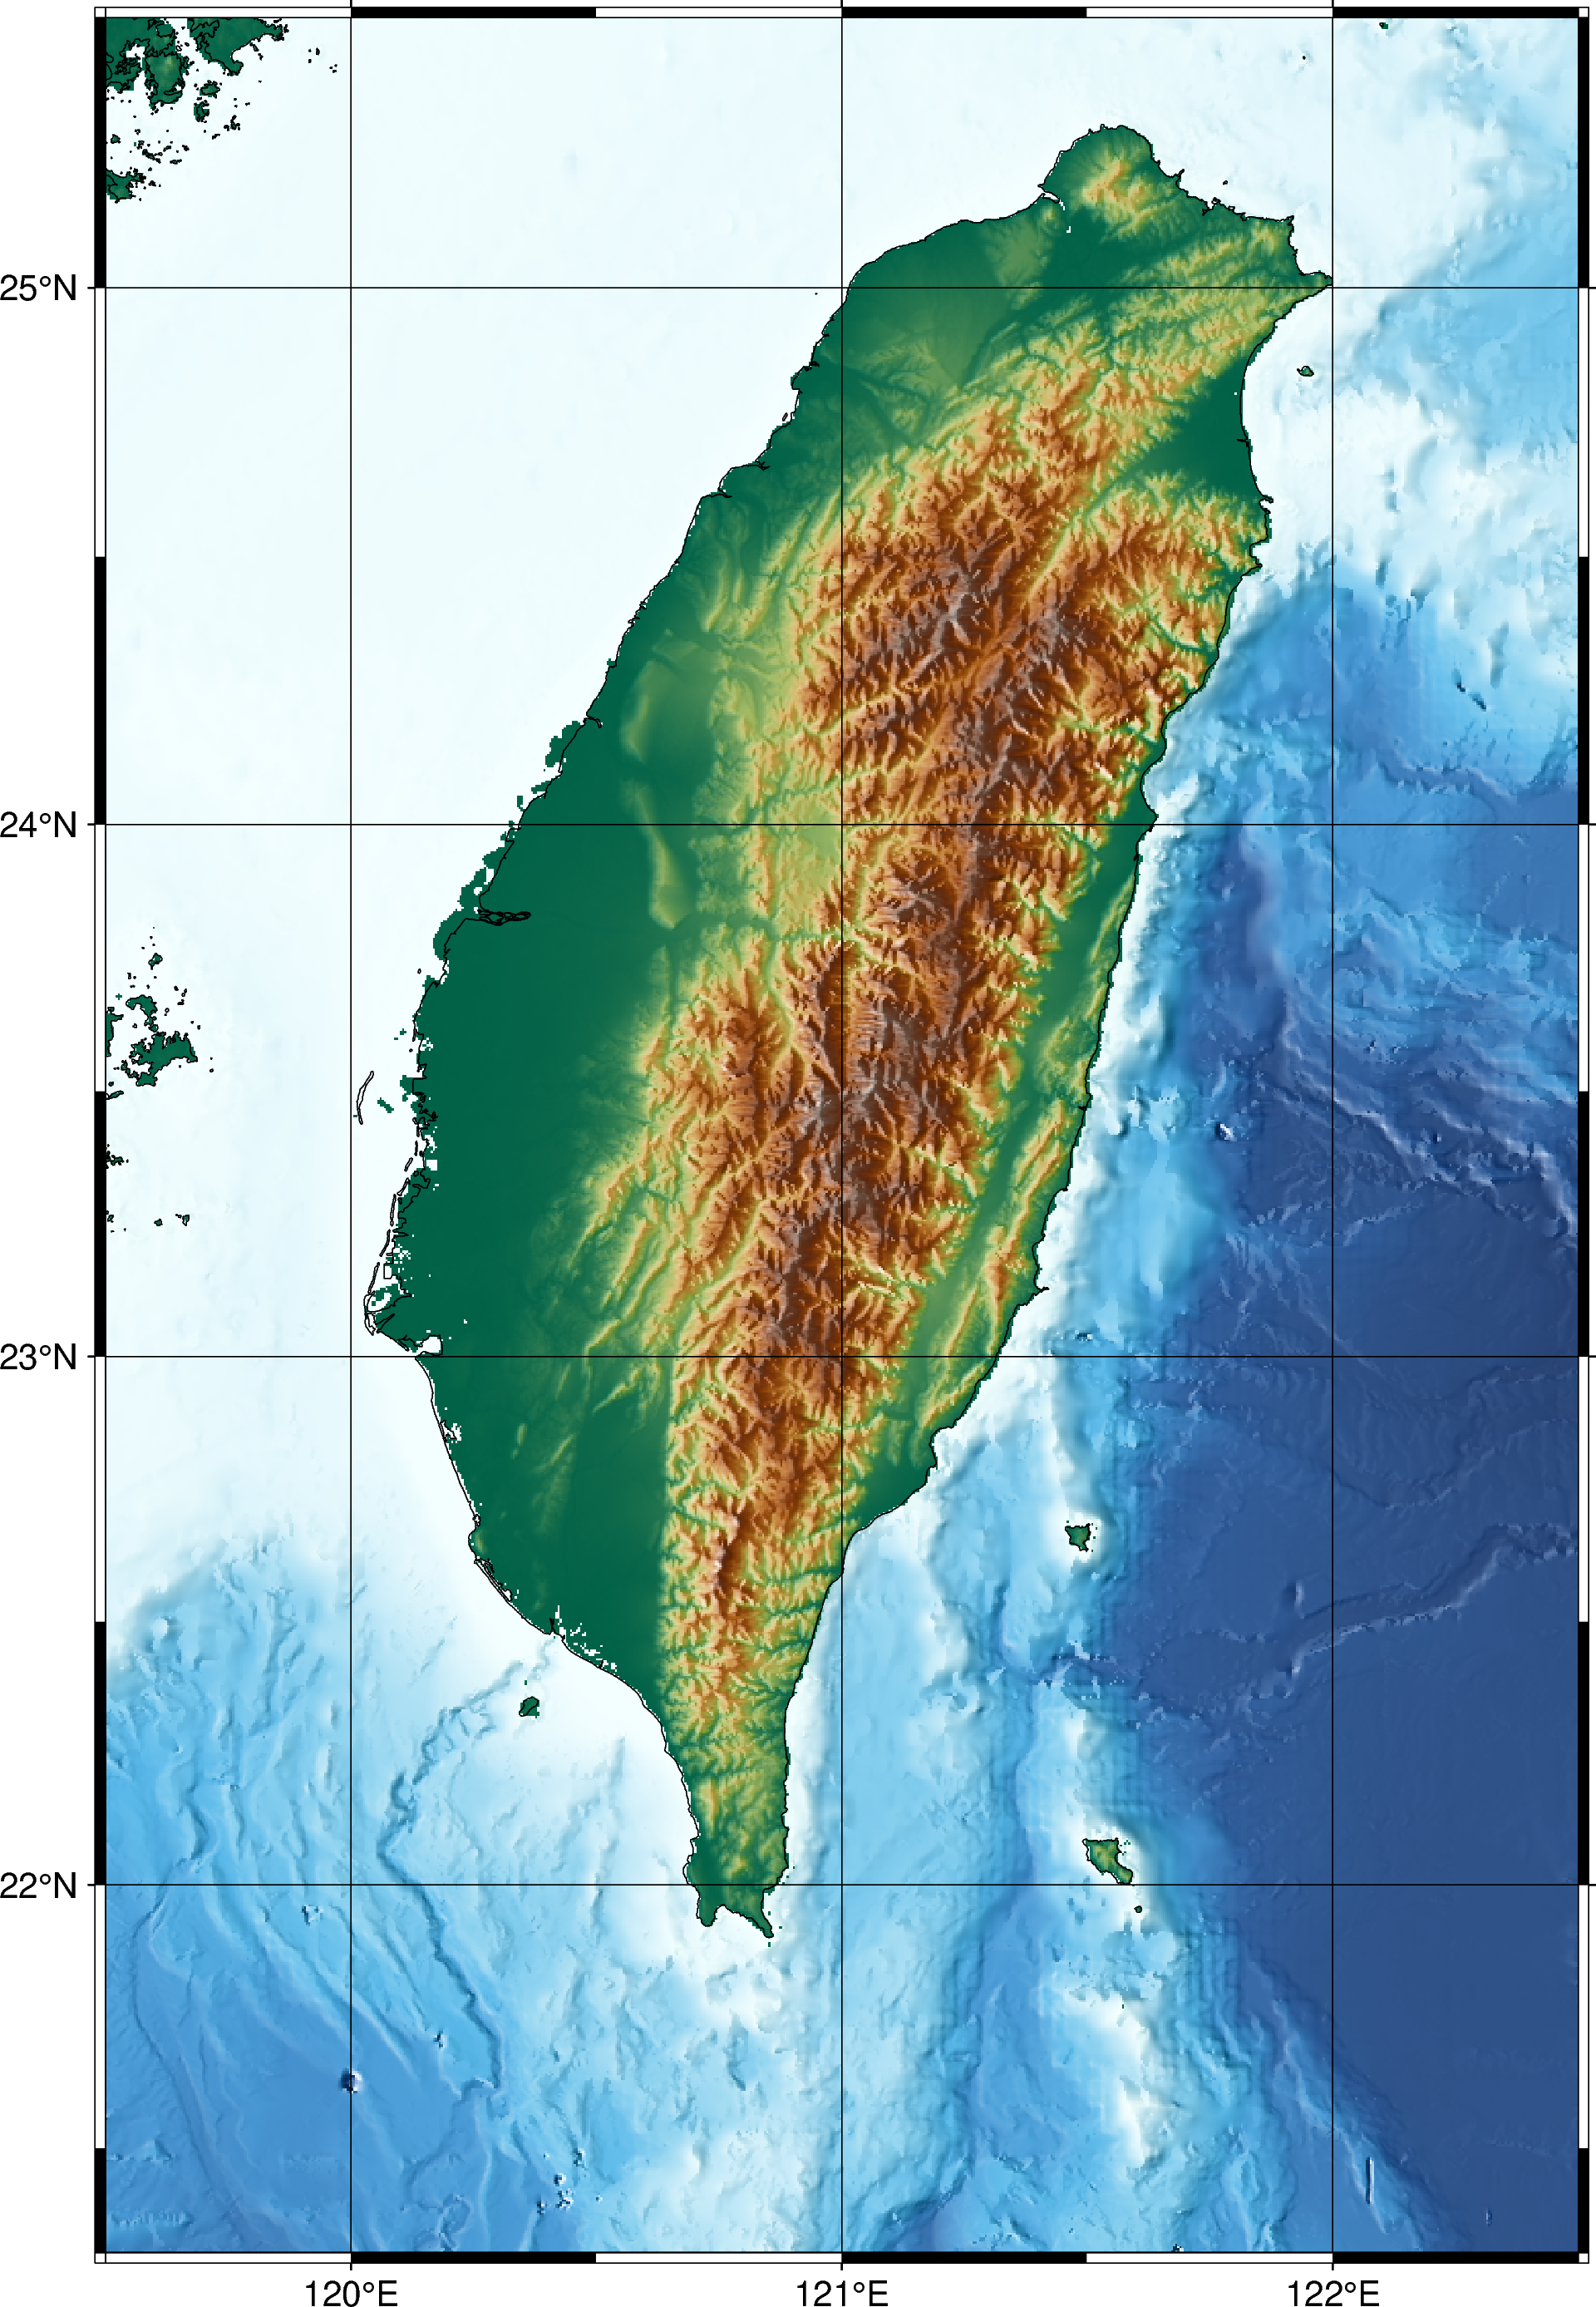

In [3]:
# DEM data using 15s resolution
region = [119.5, 122.5, 21.3, 25.5]
grid = pygmt.datasets.load_earth_relief(resolution="15s", region=region)

# Define hillshade (for terrain contrast)
intensity_grid = pygmt.grdgradient(grid=grid, azimuth=[225, 315])

# CPT
pygmt.makecpt(
    cmap="geo",
    series=[-8000, 7000, 500],
    continuous=True,
    output="eleva.cpt",
)

fig = pygmt.Figure()

# Setting map base (region, mountains, coast, topographic details)
fig.grdimage(grid=grid, 
              region=region, 
              projection="M121/15c", # changed projection for a traditional rectangular map
              cmap="eleva.cpt",
              shading=intensity_grid)

fig.coast(region=region, 
          projection="M121/15c", 
          borders="2/0.5p,black",
          shorelines=True, 
          frame=["WSne", "a1f0.5g1"])


fig.show()

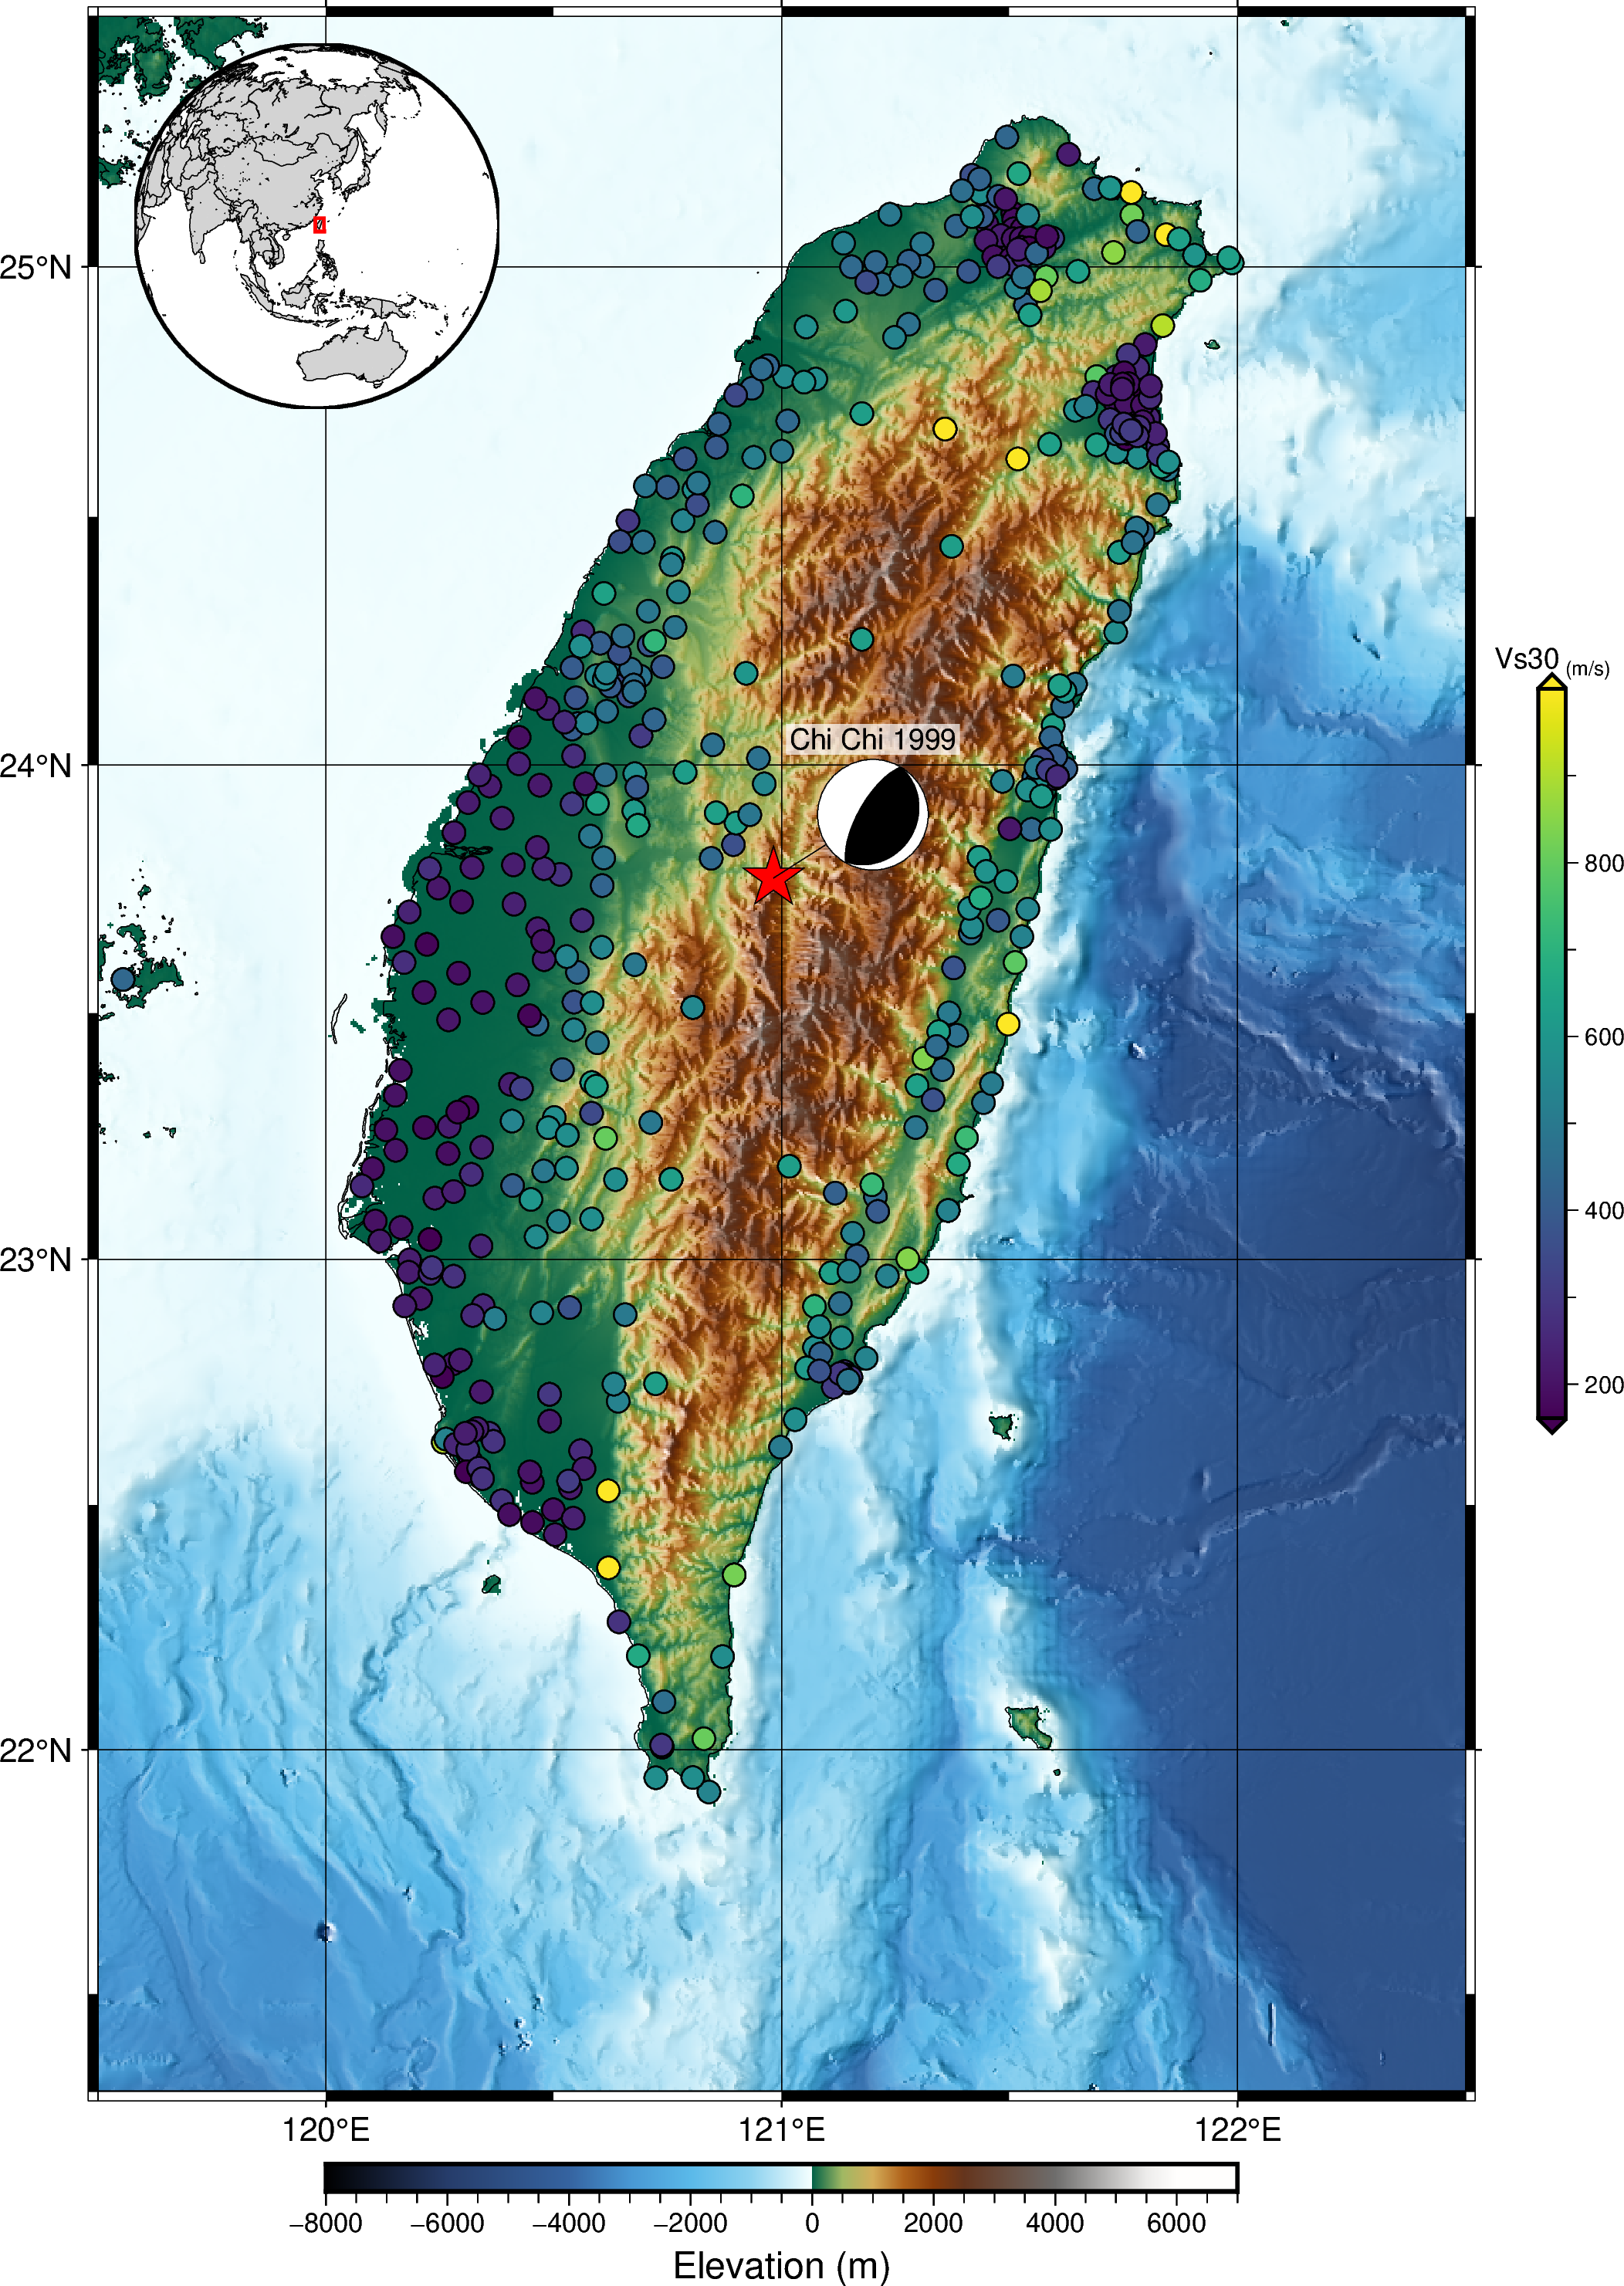

In [9]:
# Setting up the base map
# DEM data using 15s resolution
region = [119.5, 122.5, 21.3, 25.5]
grid = pygmt.datasets.load_earth_relief(resolution="15s", region=region)

# Define hillshade (for terrain contrast)
intensity_grid = pygmt.grdgradient(grid=grid, azimuth=[225, 315])

# CPT
pygmt.makecpt(
    cmap="geo",
    series=[-8000, 7000, 500],
    continuous=True,
    output="eleva.cpt",
)

fig = pygmt.Figure()

# Setting map base (region, mountains, coast, topographic details)
fig.grdimage(grid=grid, 
              region=region, 
              projection="M121/15c", # changed projection for a traditional rectangular map
              cmap="eleva.cpt",
              shading=intensity_grid)

fig.coast(region=region, 
          projection="M121/15c", 
          borders="2/0.5p,black",
          shorelines=True, 
          frame=["WSne", "a1f0.5g1"])

# Location of epicenter according to USGS
fig.plot(
    x=120.982,
    y=23.772,
    style="a0.7c",
    fill="red",
    pen="black",
)

# Adding beachball (NP2 was selected as it was more physically realistic to the Chelungpu fault)
focal_mechanism = {
    "longitude": 120.982,
    "latitude": 23.772,
    "depth": 15.5,
    "strike": 32, 
    "dip": 21,
    "rake": 92,
    "magnitude": 7.59,
    "plot_longitude": 121.2,
    "plot_latitude": 23.9,
    "event_name": "Chi Chi 1999"
}

fig.meca(
    spec=focal_mechanism,
    scale="0.8c",
    label_box="white@30",
    offset=True,
)

fig.colorbar(
    cmap="eleva.cpt", 
    frame=["a2000f500", "x+lElevation (m)"], 
    position="JBC+o0c/0.8c+w10c/0.3c+h"
)

# Inserting an inset map
from pygmt.params import Box, Position

with fig.inset(position=Position("TL", offset=(0.4, 0.3)), width=4):
     fig.coast(
        region="g",
        projection="G120/23/?",   
        land="lightgray",
        borders=1,
        shorelines=True,
        water="white"
    )
     fig.basemap(frame="p")
     rectangle = [[region[0], region[2], region[1], region[3]]]
     fig.plot(data=rectangle, style="r+s", pen="1p,red")


# Including taiwan's strong motion data
data = pd.read_csv("nga_west2_stations_taiwan.csv")

# Limiting the range of the colorbar (not controlled by outliers)
vmin = data.Vs30_m_s.quantile(0.01)
vmax = data.Vs30_m_s.quantile(0.99)

pygmt.makecpt(
    cmap="viridis", 
    series=[vmin, vmax], 
    background=True,
    output="vs30.cpt"
)

# Plot strong ground motion stations + color dependant on Vs30
fig.plot(
    x=data.Longitude,
    y=data.Latitude,
    fill=data.Vs30_m_s,
    cmap="vs30.cpt",
    style="c0.25c",
    pen="0.5p,black"
)

fig.colorbar(
    cmap="vs30.cpt", 
    frame=["a200f100", "y+lV@_s30@- (m/s)"],
    position="JMR+o0.8c/0c+w8c/0.3c+e"
)

fig.show()
